# 实验 6 —— 随机逼近与 PyTorch

在本实验中，我们将学习**随机逼近（stochastic approximation）**——一类用**基于样本的更新**来替代精确期望计算的方法。

## 🎯 实验目标

* 理解 **Robbins–Monro 随机逼近方法**及其与均值估计之间的联系。
* 使用 NumPy / PyTorch 实现 **SGD（单样本更新）**。
* 使用 **PyTorch 的自动求导（autograd）**，避免手动编写梯度代码。
* 将 SGD 扩展到 **mini-batch（小批量）SGD**，并比较不同方法的行为。


### 第一部分：平均更新规则（Averaging Update Rule）

我们从如下递推更新公式开始：

$
w_{k+1} = w_k - \frac{1}{k}\bigl(w_k - x_k\bigr)
$

这个表达式可以改写为：

$
w_{k+1} = \left(1 - \frac{1}{k}\right) w_k + \frac{1}{k} x_k,
$

该形式表明，$ w_k $ 实际上是所有历史样本 $ x_1, x_2, \ldots, x_k $ 的**运行平均（running average）**。


In [1]:
import numpy as np

# generate some random data samples
np.random.seed(0)
x = np.random.randn(10)
print("Samples:", np.round(x, 3))

# initialize
w = 0.0
w_list = []

# recursive averaging using the update rule
for k in range(1, len(x)+1):

    # w_k = w_{k-1} - (1/k)(w_{k-1} - x_k)
    w = w - (1.0 / k) * (w - x[k-1])

    w_list.append(w)

# direct averages for comparison
mean_list = [np.mean(x[:k]) for k in range(1, len(x)+1)]

# compare both sequences
print("\nStep | Recursive w_k | Direct mean")
print("-"*35)
for k, (wk, mk) in enumerate(zip(w_list, mean_list), 1):
    print(f"{k:>4} | {wk:>13.6f} | {mk:>13.6f}")


Samples: [ 1.764  0.4    0.979  2.241  1.868 -0.977  0.95  -0.151 -0.103  0.411]

Step | Recursive w_k | Direct mean
-----------------------------------
   1 |      1.764052 |      1.764052
   2 |      1.082105 |      1.082105
   3 |      1.047649 |      1.047649
   4 |      1.345960 |      1.345960
   5 |      1.450280 |      1.450280
   6 |      1.045687 |      1.045687
   7 |      1.032030 |      1.032030
   8 |      0.884107 |      0.884107
   9 |      0.774404 |      0.774404
  10 |      0.738023 |      0.738023


## 第二部分：Robbins–Monro 算法 —— 收敛性示例

现在我们来说明 **Robbins–Monro 随机逼近算法**。

该算法的目标是找到一个未知函数 $g(x)$ 的根 $x^\star$，使得：

$
g(x^\star) = 0
$

---

### 示例设置

* $ g(x) = \tanh(x - 1) $
* 真实根为：$ x^\star = 1 $
* 步长（学习率）：$ a_k = \frac{1}{k} $
* 无噪声情况：$ \eta_k = 0 $

在这种设定下，Robbins–Monro 的更新公式为：

$
w_{k+1} = w_k - a_k g(w_k)
$

将其展开，可以得到：

$
w_{k+1} = w_k - \frac{1}{k} \tanh(w_k - 1).
$


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Robbins–Monro parameters
def g(x):
    return np.tanh(x - 1)

def robbins_monro(w0=3.0, steps=100):
    w = w0
    ws = [w]
    for k in range(1, steps + 1):

        # Robbins–Monro: w_{k+1} = w_k - a_k g(w_k), a_k = 1/k
        a_k = 1.0 / k
        w = w - a_k * g(w)

        ws.append(w)
    return np.array(ws)

ws = robbins_monro(w0=3.0, steps=100)

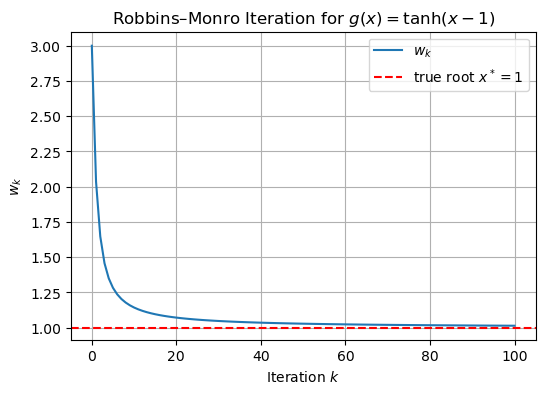

In [3]:
plt.figure(figsize=(6,4))
plt.plot(ws, label=r"$w_k$")
plt.axhline(1.0, color='red', linestyle='--', label=r"true root $x^*=1$")
plt.xlabel("Iteration $k$")
plt.ylabel("$w_k$")
plt.title("Robbins–Monro Iteration for $g(x)=\\tanh(x-1)$")
plt.legend()
plt.grid(True)
plt.show()


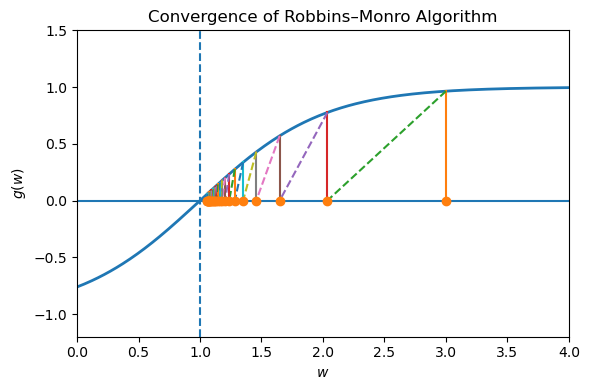

In [4]:
def robbins_monro_path(w0=3.0, steps=15):
    w = float(w0)
    ws = [w]
    segs = []  # list of ((x0,y0),(x1,y1)) segments for cobweb
    for k in range(1, steps+1):
        gw = g(w)
        # vertical up: (w_k, 0) -> (w_k, g(w_k))
        segs.append(((w, 0.0), (w, gw)))
        # horizontal/diagonal back to axis: (w_k, g(w_k)) -> (w_{k+1}, 0)
        a_k = 1.0 / k
        w_next = w - a_k * gw
        segs.append(((w, gw), (w_next, 0.0)))
        w = w_next
        ws.append(w)
    return np.array(ws), segs

# Build trajectory
ws, segs = robbins_monro_path(w0=3.0, steps=25)

# Plot g(w)
wgrid = np.linspace(0, 4, 400)
plt.figure(figsize=(6,4))
plt.plot(wgrid, g(wgrid), linewidth=2)

# Axes lines and true root
plt.axhline(0.0, linestyle='-')
plt.axvline(1.0, linestyle='--')

# Cobweb segments
for (x0,y0),(x1,y1) in segs:
    # up to curve
    if y1 != 0.0:
        plt.plot([x0,x1],[y0,y1], linestyle='-')
    # down to axis
    else:
        plt.plot([x0,x1],[y0,y1], linestyle='--')

# Mark w_k points on the axis
plt.plot(ws, np.zeros_like(ws), marker='o', linestyle='')

# Labels / limits
plt.xlabel("$w$")
plt.ylabel("$g(w)$")
plt.title(r"Convergence of Robbins–Monro Algorithm")
plt.xlim(0,4)
plt.ylim(-1.2,1.5)
plt.tight_layout()
plt.show()


## 第三部分：全梯度下降（Full Gradient Descent）

我们考虑如下优化问题：
$$
J(\mathbf w)=\mathbb E!\left[\tfrac12\lVert \mathbf w-\mathbf X\rVert^2\right],
\qquad
f(\mathbf w,\mathbf X)=\tfrac12\lVert \mathbf w-\mathbf X\rVert^2,
\qquad
\nabla_{\mathbf w} f(\mathbf w,\mathbf X)=\mathbf w-\mathbf X.
$$

该问题可以解释为一个在**高斯分布下的均值估计问题**：

* 假设随机变量 $\mathbf X \sim \mathrm{Normal}(\boldsymbol\mu, \Sigma)$；
* 目标是找到参数向量 $\mathbf w$，使其与样本 $\mathbf X$ 之间的**期望平方距离最小**；
* 函数 $f(\mathbf w, \mathbf X)$ 表示在观测到样本 $\mathbf X$ 时选择 $\mathbf w$ 的“瞬时损失”；
* 期望损失 $J(\mathbf w)$ 在 $\mathbf w$ 等于**真实均值** $\boldsymbol\mu$ 时达到最小。

由于期望是对 $\mathbf X$ 取的，有：
$$
\nabla J(\mathbf w)=\mathbb E[\mathbf w-\mathbf X]=\mathbf w-\boldsymbol\mu,
\quad\text{其中 } \boldsymbol\mu=\mathbb E[\mathbf X].
$$

因此，最优解为：
$$
\mathbf w^\star=\boldsymbol\mu.
$$

**全梯度下降（确定性梯度下降）**在步长 $\eta>0$ 下的更新公式为：
$$
\mathbf w_{k+1}
= \mathbf w_k - \eta,(\mathbf w_k-\boldsymbol\mu)
= (1-\eta),\mathbf w_k + \eta,\boldsymbol\mu .
$$


In [5]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([1.5, 0.7])   # true mean
eta = 0.3                   # step size, must satisfy 0 < eta < 2
w0 = np.array([3.0, -1.5])  # starting point
steps = 7

def J(w, mu):
    return 0.5*np.sum((w - mu)**2)

# run GD
ws = [w0.copy()]
w = w0.copy()
for k in range(steps):

    # Full gradient descent update
    grad = w - mu           # ∇J(w) = w - μ
    w = w - eta * grad
    ws.append(w.copy())
ws = np.array(ws)

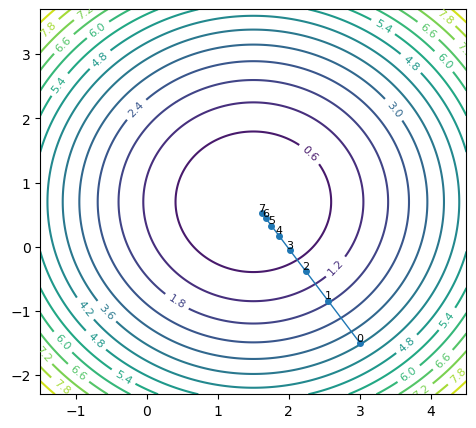

In [6]:
# Plotting functions
xx = np.linspace(mu[0]-3.0, mu[0]+3.0, 201)
yy = np.linspace(mu[1]-3.0, mu[1]+3.0, 201)
XX, YY = np.meshgrid(xx, yy)
ZZ = 0.5*((XX-mu[0])**2 + (YY-mu[1])**2)
plt.figure(figsize=(5.5,5))
CS = plt.contour(XX, YY, ZZ, levels=15)
plt.clabel(CS, inline=1, fontsize=8)

plt.plot(ws[:,0], ws[:,1], marker='o', linewidth=1, ms=4)

for i in range(len(ws)):
    plt.text(ws[i,0], ws[i,1], str(i), fontsize=8, ha='center', va='bottom')

## 第四部分：随机梯度下降（Stochastic Gradient Descent, SGD）

### 🧩 第一步：采样数据点（Sampling Data Points）

在实际问题中，我们通常**无法获得完整的函数或数据分布信息**，只能观测到从该分布中采样得到的**有限样本**。例如，在机器学习中，我们并不知道输入与输出之间的真实关系，只能依赖从现实世界收集到的数据点。

为了模拟这种情况，我们从一个**二维高斯分布（2D Gaussian distribution）**中生成 **40 个随机样本**，其真实均值是已知但在算法中“不可见”的。

接下来的目标是，在不知道真实均值的前提下，使用**随机梯度下降（SGD）**来对该均值进行估计。


In [7]:
# ----- 1) Sample 40 points -----
np.random.seed(7)
mu_true = np.array([1.5, 0.7])
Sigma = np.array([[0.5, 0.2],
                  [0.2, 0.3]])
N = 40
X = np.random.multivariate_normal(mu_true, Sigma, size=N)
X_bar = X.mean(axis=0)

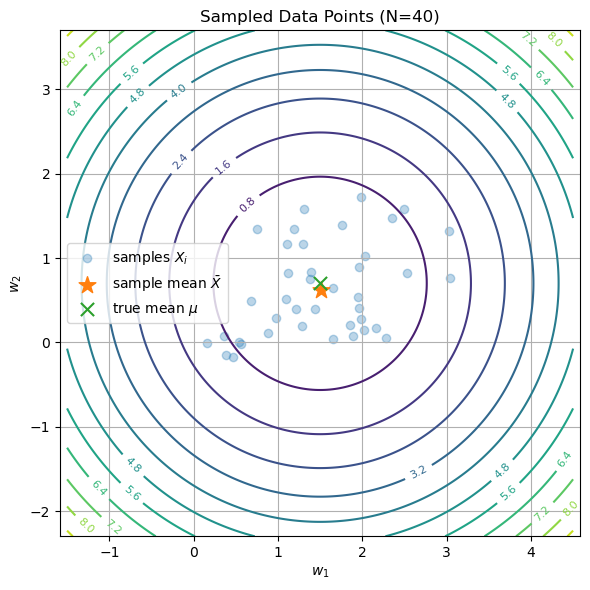

In [8]:
# ----- 2) Plot dataset, contours -----
plt.figure(figsize=(6,6))
cs = plt.contour(xx, yy, ZZ, levels=12)
plt.clabel(cs, inline=1, fontsize=8)

# data points and means
plt.scatter(X[:,0], X[:,1], alpha=0.3, label="samples $X_i$")
plt.scatter(X_bar[0], X_bar[1], marker="*", s=160, label="sample mean $\\bar X$")
plt.scatter(mu_true[0], mu_true[1], marker="x", s=90, label="true mean $\\mu$")


plt.title("Sampled Data Points (N=40)")
plt.xlabel("$w_1$"); plt.ylabel("$w_2$")
plt.axis("equal"); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

### 🧩 第二步：随机梯度下降（SGD）

然而，在实际情况下，我们每次只能观测到一个样本 $\mathbf X_i$。
为了近似真实梯度，我们使用该单个样本对应的**瞬时梯度（instantaneous gradient）**：

$
\nabla_{\mathbf w} f(\mathbf w, \mathbf X_i) = \mathbf w - \mathbf X_i.
$

然后，根据随机梯度下降（SGD）的更新规则，对参数进行迭代更新：

$
\mathbf w_{t+1} = \mathbf w_t - \eta , (\mathbf w_t - \mathbf X_i),
$

其中 $\eta > 0$ 是**学习率（learning rate）**，用于控制每一步更新的步长大小。


In [9]:
eta = 0.3           # 0 try 0.3 or 0.9 to see different behavior
epochs = 1

w = w0.copy()
ws = [w.copy()]
loss_hist = []

rng = np.random.default_rng(0)
for ep in range(epochs):
    idx = np.arange(N)
    #rng.shuffle(idx) # pick a random data
    for i in idx:

        # SGD with one sample
        grad_i = w - X[i]          # ∇(1/2)||w - X_i||^2
        w = w - eta * grad_i
        ws.append(w.copy())
        loss_hist.append(0.5 * np.sum((w - X[i])**2))


ws = np.array(ws)

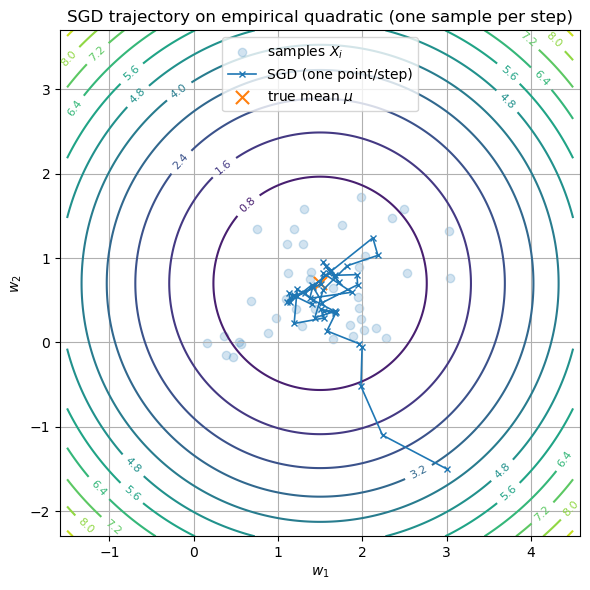

In [10]:
plt.figure(figsize=(6,6))
cs = plt.contour(xx, yy, ZZ, levels=12)
plt.clabel(cs, inline=1, fontsize=8)

plt.scatter(X[:,0], X[:,1], alpha=0.2, label="samples $X_i$")
plt.plot(ws[:,0], ws[:,1], marker='x', ms=5, linewidth=1.2, label="SGD (one point/step)")
plt.scatter(mu_true[0], mu_true[1], marker="x", s=90, label="true mean $\\mu$")

plt.title("SGD trajectory on empirical quadratic (one sample per step)")
plt.xlabel("$w_1$"); plt.ylabel("$w_2$")
plt.axis("equal"); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

### ⚙️ 第五部分：使用 PyTorch —— 无需手动计算 SGD 的梯度

借助 **PyTorch 的自动求导（autograd）机制**，我们不再需要手动推导或编写梯度公式（例如 $\nabla_{\mathbf w} f(\mathbf w,\mathbf X)=\mathbf w-\mathbf X$）。

相反，我们只需要**用张量（tensor）构建计算过程**，PyTorch 就会通过**反向模式自动微分（reverse-mode autodiff）**自动计算所需的梯度。



In [11]:
import torch
# Torch tensors
device = "cuda"
X_torch = torch.from_numpy(X).float().to(device)
X_bar = X_torch.mean(dim=0)

# w become the parameter we want to estimate (2D)
w = torch.nn.Parameter(torch.tensor([3.0, -1.5], dtype=torch.float32, device=device))

# One-sample-at-a-time SGD (you can also use torch.optim.SGD with batch_size=1; here we show manual control)
eta = 0.3
epochs = 1

# Hyperparameters
eta = 0.1
epochs = 3  # how many times we loop through the dataset
ws = []     # record trajectory

for epoch in range(epochs):
    # shuffle the data order at each epoch
    indices = torch.arange(N)
    #indices = torch.randperm(len(X_torch))

    for i in indices:
        Xi = X_torch[i]

        # one-sample loss
        loss = 0.5 * torch.sum((w - Xi) ** 2)
        loss.backward()

        # SGD update
        with torch.no_grad():
            w -= eta * w.grad    # loss.backward() + w.grad gives you the gradient

        # clear gradient buffer
        w.grad.zero_()
        # record current w for visualization
        ws.append(w.detach().clone())
ws = torch.stack(ws).cpu().numpy()

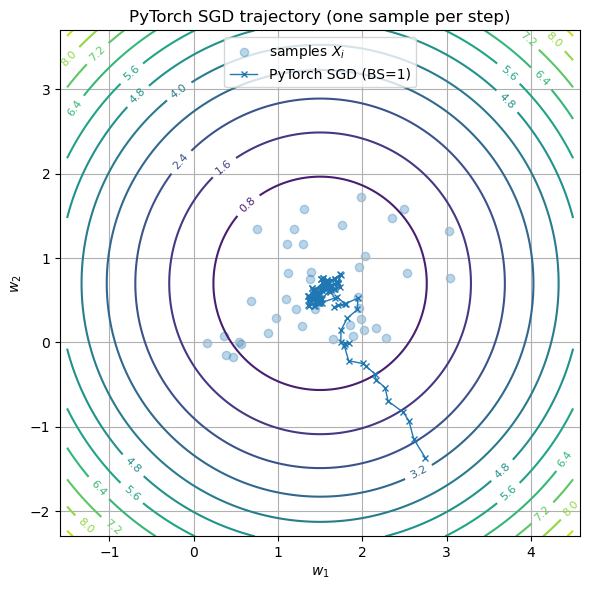

In [12]:
plt.figure(figsize=(6,6))
cs = plt.contour(xx, yy, ZZ, levels=12)
plt.clabel(cs, inline=1, fontsize=8)
plt.scatter(X[:,0], X[:,1], alpha=0.3, label="samples $X_i$")
#plt.scatter(Xbar_np[0], Xbar_np[1], marker="*", s=160, label="sample mean $\\bar X$")
plt.plot(ws[:,0], ws[:,1], marker='x', ms=4, linewidth=1., label="PyTorch SGD (BS=1)")
plt.title("PyTorch SGD trajectory (one sample per step)")
plt.xlabel("$w_1$"); plt.ylabel("$w_2$")
plt.axis("equal"); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()


### 📦 第六部分：小批量 SGD 与 PyTorch 优化器

为了减小单样本更新带来的方差，并更好地利用向量化计算能力，我们将从**单样本 SGD**切换到**小批量 SGD（mini-batch SGD）**：

* 使用 **DataLoader** 按照**每批 4 个样本**的方式迭代数据；
* 将小批量损失函数定义为
  $
  \frac{1}{B}\sum_{i=1}^{B} \tfrac12 \lVert \mathbf w - \mathbf X_i \rVert^2,
  $
  也就是一个批次内各样本平方距离损失的平均值；
* 使用 **`torch.optim.SGD`** 让 PyTorch 自动完成梯度计算和参数更新；
* 在每次优化器更新之后，记录参数 $ \mathbf w $，以便后续可视化其迭代轨迹。

这样做保持了原来的目标不变——仍然是在估计高斯分布的均值——但相比单样本 SGD，参数更新会**更加稳定**。


In [13]:
# ----- Batched SGD with batch_size=4 using torch.optim.SGD -----

from torch.utils.data import TensorDataset, DataLoader

device = "cuda"

# Assume X (Nx2 numpy) and mu_true, N are already defined
X_torch = torch.from_numpy(X).float().to(device)
X_bar   = X_torch.mean(dim=0)

# Parameter to estimate (2D mean)
w = torch.nn.Parameter(torch.tensor([3.0, -1.5], dtype=torch.float32, device=device))

# DataLoader for mini-batch sampling
batch_size = 4
dataset = TensorDataset(X_torch)                 # each item is (Xi,)
loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

# Optimizer hyperparams
eta    = 0.1
epochs = 4
opt    = torch.optim.SGD([w], lr=eta) # we now use an optimizer to update w

# record trajectory of w
ws = []

for epoch in range(epochs):
    for (Xb,) in loader:  # Xb: [B, 2]
        # Mini-batch loss: average of 0.5 * ||w - Xi||^2 over the batch
        # Broadcast w (2,) against Xb (B,2) -> per-sample squared norms then mean
        per_sample = 0.5 * torch.sum((w - Xb) ** 2, dim=1)
        loss = per_sample.mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        ws.append(w.detach().clone())

ws = torch.stack(ws).cpu().numpy()

print("Final estimate (w):", w.detach().cpu().numpy())
print("Sample mean (X_bar):", X_bar.detach().cpu().numpy())
print("True mean (mu_true):", mu_true)


Final estimate (w): [1.5087593 0.5820507]
Sample mean (X_bar): [1.5049709 0.6171909]
True mean (mu_true): [1.5 0.7]


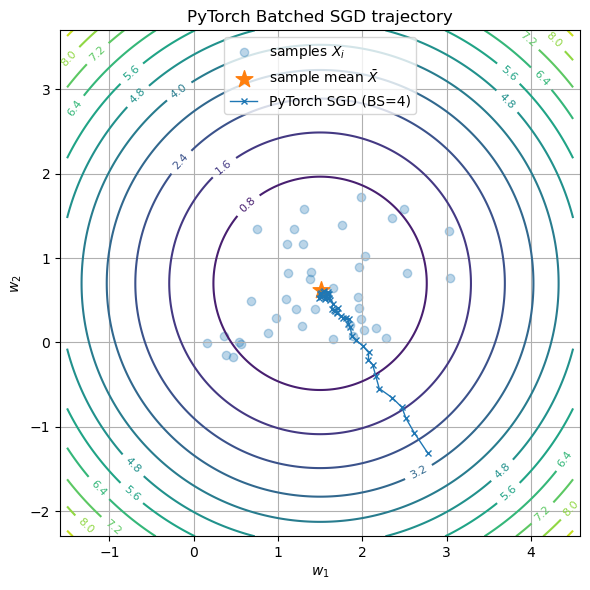

In [14]:
plt.figure(figsize=(6,6))
cs = plt.contour(xx, yy, ZZ, levels=12)
plt.clabel(cs, inline=1, fontsize=8)
plt.scatter(X[:,0], X[:,1], alpha=0.3, label="samples $X_i$")
Xbar_np = X_bar.detach().cpu().numpy()
plt.scatter(Xbar_np[0], Xbar_np[1], marker="*", s=160, label="sample mean $\\bar X$")
plt.plot(ws[:,0], ws[:,1], marker='x', ms=4, linewidth=1., label="PyTorch SGD (BS=4)")
plt.title("PyTorch Batched SGD trajectory")
plt.xlabel("$w_1$"); plt.ylabel("$w_2$")
plt.axis("equal"); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

## 🧩 第七部分：使用小批量 SGD 训练 MNIST（PyTorch）

在这个示例中，你将使用**小批量 SGD（mini-batch SGD）**在 **MNIST** 数据集上训练一个简单的分类器。

我们将使用以下组件：

* `DataLoader`（用于生成小批量数据，并支持打乱顺序）；
* 一个简单的**卷积神经网络（CNN）**（如果需要，也可以替换为多层感知机 MLP）；
* `torch.optim.SGD`（可以调节 `lr`、`momentum`、`batch_size` 等超参数）；
* 标准的**训练 / 测试（train / eval）循环**，并输出分类准确率。

**建议尝试：**

* 对比不同的批大小：`batch_size ∈ {1, 32, 128}`；
* 调整学习率 `lr`；
* 开启或关闭 `momentum`；

观察这些设置对训练**稳定性**和**收敛速度**的影响。


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import random
import os

In [16]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)   # 28x28 -> 28x28
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)  # 14x14 -> 14x14
        self.fc1   = nn.Linear(32*7*7, 64)
        self.fc2   = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))         # [B,16,28,28]
        x = F.max_pool2d(x, 2)            # [B,16,14,14]
        x = F.relu(self.conv2(x))         # [B,32,14,14]
        x = F.max_pool2d(x, 2)            # [B,32,7,7]
        x = x.view(x.size(0), -1)         # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [17]:
# ----- Train / Eval Loops -----
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        # forward
        logits = model(x)
        loss = criterion(logits, y)

        # backward + sgd step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total += x.size(0)

    return total_loss / total, total_correct / total

In [18]:
# ----- Device -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Build model after device is known
model = SmallCNN().to(device)

# ----- Data -----
# Normalize to mean=0.1307, std=0.3081 (standard for MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256,    shuffle=False, num_workers=2, pin_memory=True)


lr = 0.1
momentum = 0.0   # try 0.9 later for smoother updates
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
criterion = nn.CrossEntropyLoss()

Device: cuda


In [19]:
epochs = 3
for ep in range(1, epochs+1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)

    print(f"Epoch {ep:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc*100:5.2f}%  | "
          f"test loss {te_loss:.4f} acc {te_acc*100:5.2f}%")


Epoch 01 | train loss 0.2165 acc 93.11%  | test loss 0.0624 acc 98.03%


Epoch 02 | train loss 0.0528 acc 98.33%  | test loss 0.0507 acc 98.42%


Epoch 03 | train loss 0.0370 acc 98.86%  | test loss 0.0350 acc 98.84%
